In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from textblob import TextBlob

In [4]:
import pandas as pd

# dataset of customer phrases and their actual emotions
data = {
    "text": [
        "This product is absolutely amazing!", 
        "I am so frustrated with this service.", 
        "It's an okay experience, nothing special.",
        "The delivery was late and the box was broken.",
        "Thank you so much for the quick help ",
        "I just want to check my account balance.",
        "Worst chatbot I have ever used.",
        "Brilliant design, I love using this."
    ],
    "actual_sentiment": [
        "positive", "negative", "neutral", 
        "negative", "positive", "neutral", 
        "negative", "positive"
    ]
}

df = pd.DataFrame(data)
df

,text,actual_sentiment
0,This product is absolutely amazing!,positive
1,I am so frustrated with this service.,negative
2,"It's an okay experience, nothing special.",neutral
3,The delivery was late and the box was broken.,negative
4,Thank you so much for the quick help,positive
5,I just want to check my account balance.,neutral
6,Worst chatbot I have ever used.,negative
7,"Brilliant design, I love using this.",positive


In [5]:
from textblob import TextBlob

def analyze_sentiment(text):
   
    score = TextBlob(text).sentiment.polarity
    if score > 0.1:
        return "positive"
    elif score < -0.1:
        return "negative"
    else:
        return "neutral"
 
df['bot_prediction'] = df['text'].apply(analyze_sentiment)
df

,text,actual_sentiment,bot_prediction
0,This product is absolutely amazing!,positive,positive
1,I am so frustrated with this service.,negative,negative
2,"It's an okay experience, nothing special.",neutral,positive
3,The delivery was late and the box was broken.,negative,negative
4,Thank you so much for the quick help,positive,positive
5,I just want to check my account balance.,neutral,neutral
6,Worst chatbot I have ever used.,negative,negative
7,"Brilliant design, I love using this.",positive,positive


In [7]:
from sklearn.metrics import accuracy_score, classification_report

 
accuracy = accuracy_score(df['actual_sentiment'], df['bot_prediction'])
print(f"Bot Accuracy: {accuracy * 100:.2f}%\n")

 
print("--- Classification Report ---")
print(classification_report(df['actual_sentiment'], df['bot_prediction']))

Bot Accuracy: 87.50%

--- Classification Report ---
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         3
     neutral       1.00      0.50      0.67         2
    positive       0.75      1.00      0.86         3

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.84         8
weighted avg       0.91      0.88      0.86         8



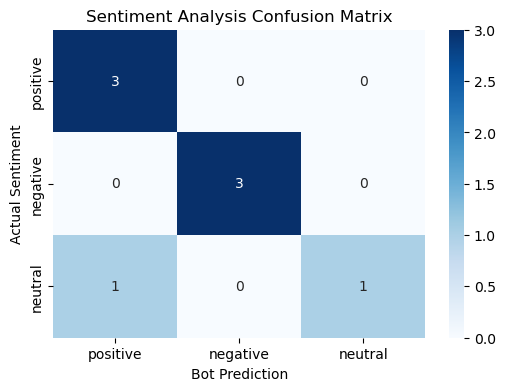

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

 
cm = confusion_matrix(df['actual_sentiment'], df['bot_prediction'], labels=["positive", "negative", "neutral"])

# Plot it using Seaborn  
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["positive", "negative", "neutral"], 
            yticklabels=["positive", "negative", "neutral"])

plt.title('Sentiment Analysis Confusion Matrix')
plt.xlabel('Bot Prediction')
plt.ylabel('Actual Sentiment')
plt.show()